# Notebook 03: Exploratory Data Analysis (EDA)

**Project:** Banking Customer Churn Intelligence — Section A, Group 9

**Problem Statement:** *What factors influence customer churn in a banking system?*

**Business Objective:** Convert raw customer data into actionable insights that help identify customers at high risk of churn, understand behavioral patterns leading to churn, and improve retention strategies.

In this notebook, we explore the cleaned dataset produced by `02_cleaning.ipynb` to uncover patterns, distributions, and relationships that may indicate churn risk.

---
## Step 1: Dataset Overview
We begin by loading the cleaned dataset and reviewing its structure, data types, and summary statistics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load the cleaned dataset
df = pd.read_csv("../data/processed/cleaned_banking_churn.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 28382 rows × 22 columns


In [3]:
# Data types overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             28382 non-null  int64  
 1   gender                          28382 non-null  object 
 2   dependents                      28382 non-null  float64
 3   occupation                      28382 non-null  object 
 4   city                            28382 non-null  float64
 5   customer_nw_category            28382 non-null  int64  
 6   current_balance                 28382 non-null  float64
 7   previous_month_end_balance      28382 non-null  float64
 8   average_monthly_balance_prevq   28382 non-null  float64
 9   average_monthly_balance_prevq2  28382 non-null  float64
 10  current_month_credit            28382 non-null  float64
 11  previous_month_credit           28382 non-null  float64
 12  current_month_debit             

In [4]:
# Summary statistics for numerical columns
df.describe().round(2)

,age,dependents,city,customer_nw_category,current_balance,previous_month_end_balance,average_monthly_balance_prevq,average_monthly_balance_prevq2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,is_active,balance_diff,customer_tenure_years
count,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00,28382.00
mean,48.21,0.31,797.18,2.23,7380.55,7495.77,7496.78,7124.21,3433.25,3261.69,3658.74,3339.76,7451.13,7495.18,0.19,0.89,-114.63,5.73
std,17.81,0.80,426.75,0.66,42598.71,42529.35,41726.22,44575.81,77071.45,29688.89,51985.42,24301.11,42033.94,42431.98,0.39,0.32,14455.26,0.75
min,1.00,0.00,0.00,1.00,-5503.96,-3149.57,1428.69,-16506.10,0.01,0.01,0.01,0.01,-3374.18,-5171.92,0.00,0.00,-869454.60,0.20
25%,36.00,0.00,409.00,2.00,1784.47,1906.00,2180.95,1832.51,0.31,0.33,0.41,0.41,1996.76,2074.41,0.00,1.00,-763.14,5.36
50%,46.00,0.00,834.00,2.00,3281.26,3379.92,3542.86,3359.60,0.61,0.63,91.93,109.96,3448.00,3465.23,0.00,1.00,0.00,5.90
75%,60.00,0.00,1096.00,3.00,6635.82,6656.54,6666.89,6517.96,707.27,749.24,1360.44,1357.55,6667.96,6654.69,0.00,1.00,326.51,6.28
max,90.00,9.00,1649.00,3.00,5905904.03,5740438.63,5700289.57,5010170.10,12269845.39,2361808.29,7637857.36,1414168.06,5778184.77,5720144.50,1.00,1.00,574356.13,6.78


**Observations:**
- The dataset contains **28,382 rows** and **22 columns** after cleaning.
- Engineered features include `is_active`, `balance_diff`, `customer_tenure_years`, and `age_group`.
- Financial columns like `current_balance` show high standard deviations, indicating significant variation in customer wealth.
- The `churn` column has a mean of ~0.19, meaning roughly **19% of customers have churned** — this is an imbalanced dataset.

---
## Step 2: Univariate Analysis
### 2.1 Numerical Features
We examine the distribution of key numerical columns to understand their spread, skewness, and outliers.

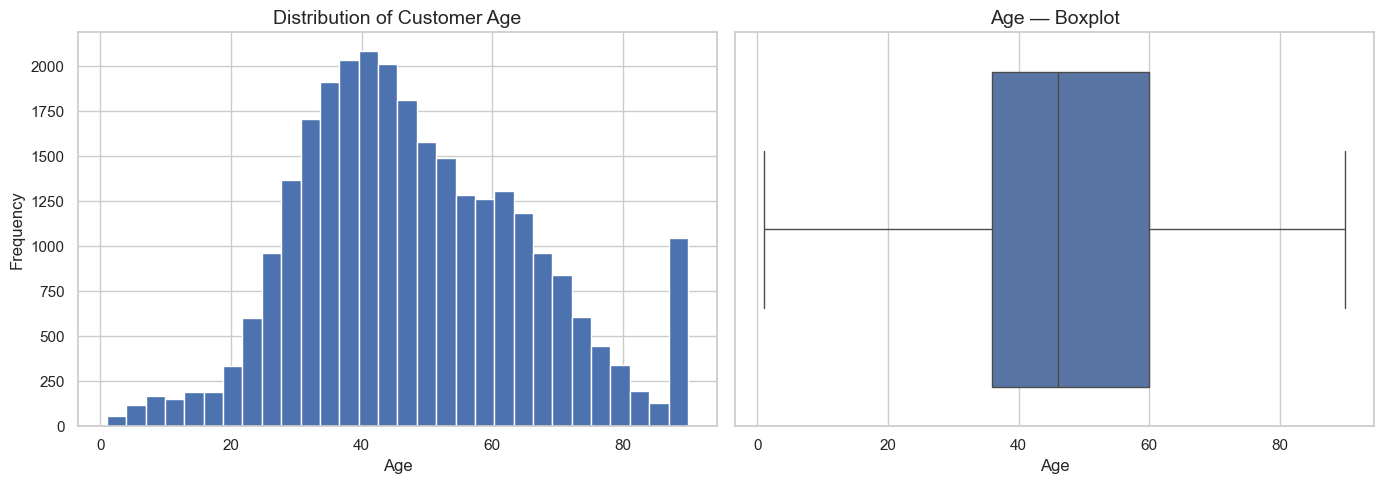

Age — Mean: 48.2, Median: 46.0, Std: 17.8


In [5]:
# Distribution of Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['age'], bins=30, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribution of Customer Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['age'], ax=axes[1], color='#4C72B0')
axes[1].set_title('Age — Boxplot')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print(f"Age — Mean: {df['age'].mean():.1f}, Median: {df['age'].median():.1f}, Std: {df['age'].std():.1f}")

**Insight:** The age distribution is roughly symmetric with a slight right skew. Most customers are between **30 and 65 years old**. The median age is around 46, indicating a predominantly middle-aged customer base.

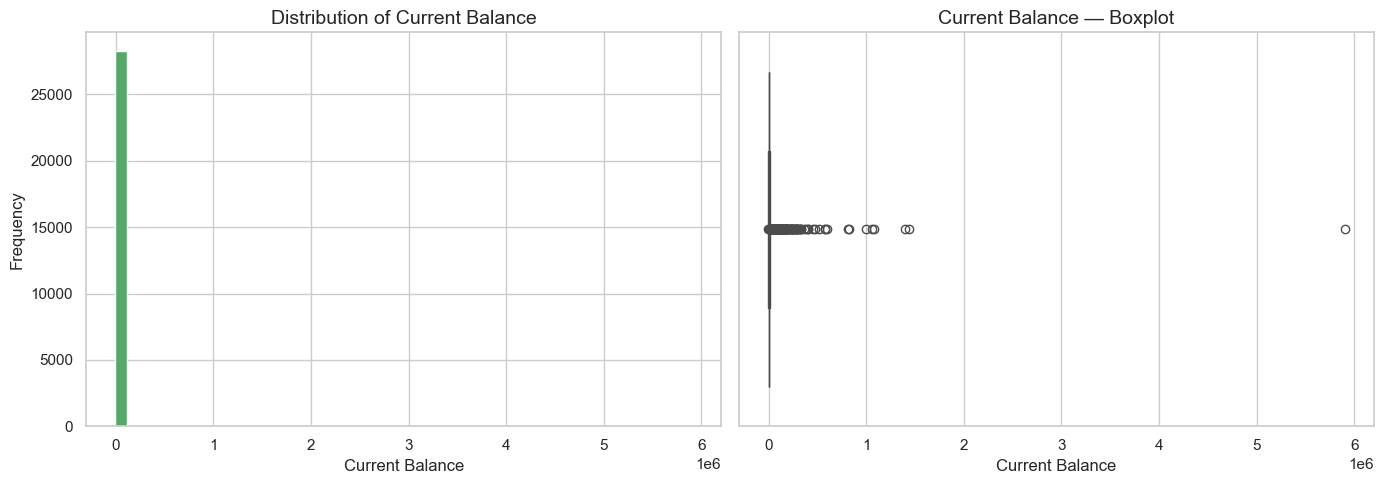

Current Balance — Mean: 7380.55, Median: 3281.26


In [6]:
# Distribution of Current Balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['current_balance'], bins=50, color='#55A868', edgecolor='white')
axes[0].set_title('Distribution of Current Balance')
axes[0].set_xlabel('Current Balance')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['current_balance'], ax=axes[1], color='#55A868')
axes[1].set_title('Current Balance — Boxplot')
axes[1].set_xlabel('Current Balance')

plt.tight_layout()
plt.show()

print(f"Current Balance — Mean: {df['current_balance'].mean():.2f}, Median: {df['current_balance'].median():.2f}")

**Insight:** Current balance is **heavily right-skewed** with most customers holding relatively low balances. A small number of high-net-worth customers pull the mean significantly above the median. This suggests a typical banking distribution with a few wealthy outliers.

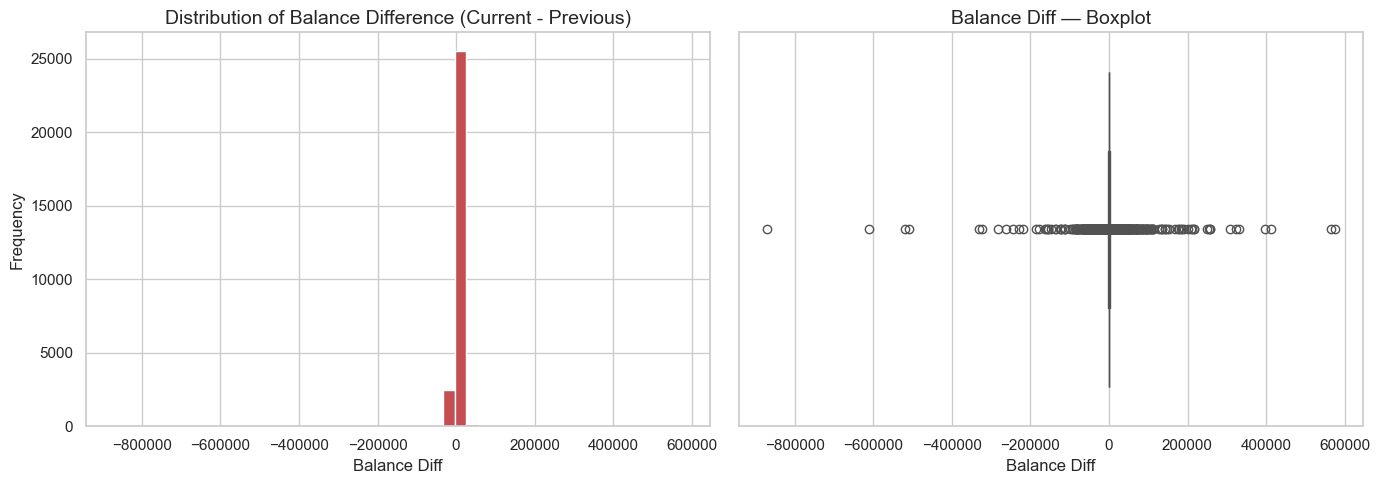

Balance Diff — Mean: -114.63, Median: 0.00


In [7]:
# Distribution of Balance Diff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['balance_diff'], bins=50, color='#C44E52', edgecolor='white')
axes[0].set_title('Distribution of Balance Difference (Current - Previous)')
axes[0].set_xlabel('Balance Diff')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['balance_diff'], ax=axes[1], color='#C44E52')
axes[1].set_title('Balance Diff — Boxplot')
axes[1].set_xlabel('Balance Diff')

plt.tight_layout()
plt.show()

print(f"Balance Diff — Mean: {df['balance_diff'].mean():.2f}, Median: {df['balance_diff'].median():.2f}")

**Insight:** The balance difference is centered near zero, indicating most customers maintain stable balances month-over-month. However, both tails show customers with **significant balance increases or decreases**, which may signal behavioral changes linked to churn.

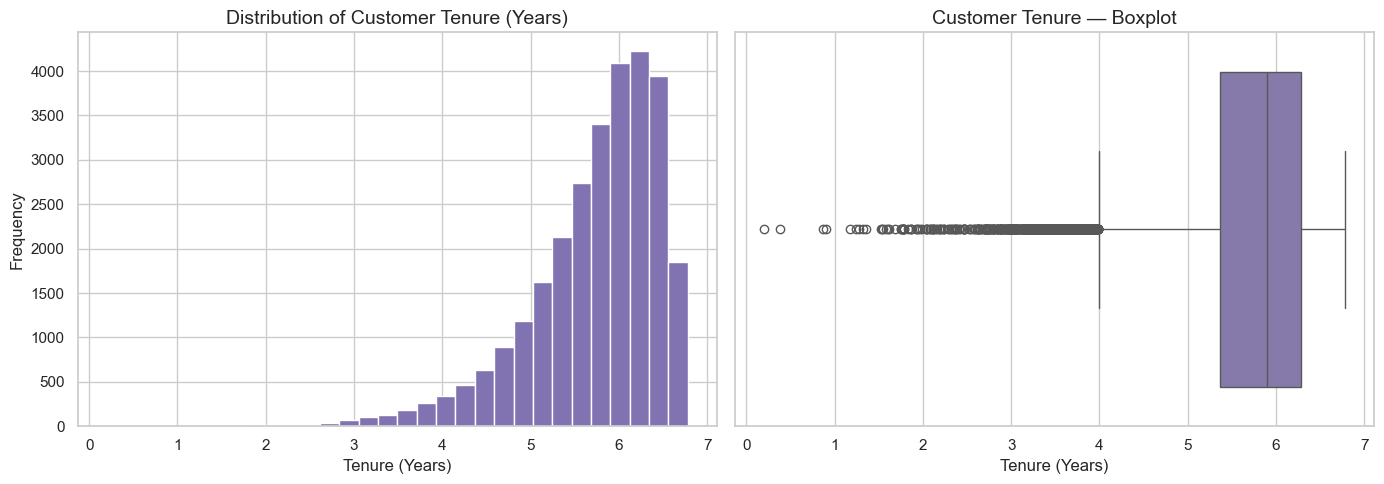

Tenure — Mean: 5.73, Median: 5.90


In [8]:
# Distribution of Customer Tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['customer_tenure_years'], bins=30, color='#8172B2', edgecolor='white')
axes[0].set_title('Distribution of Customer Tenure (Years)')
axes[0].set_xlabel('Tenure (Years)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['customer_tenure_years'], ax=axes[1], color='#8172B2')
axes[1].set_title('Customer Tenure — Boxplot')
axes[1].set_xlabel('Tenure (Years)')

plt.tight_layout()
plt.show()

print(f"Tenure — Mean: {df['customer_tenure_years'].mean():.2f}, Median: {df['customer_tenure_years'].median():.2f}")

**Insight:** Customer tenure is left-skewed — most customers have been with the bank for **5 to 7 years**. Few customers have very short tenures, which may indicate either recent acquisitions or data entry timing.

### 2.2 Categorical Features
We now examine the distribution of categorical variables.

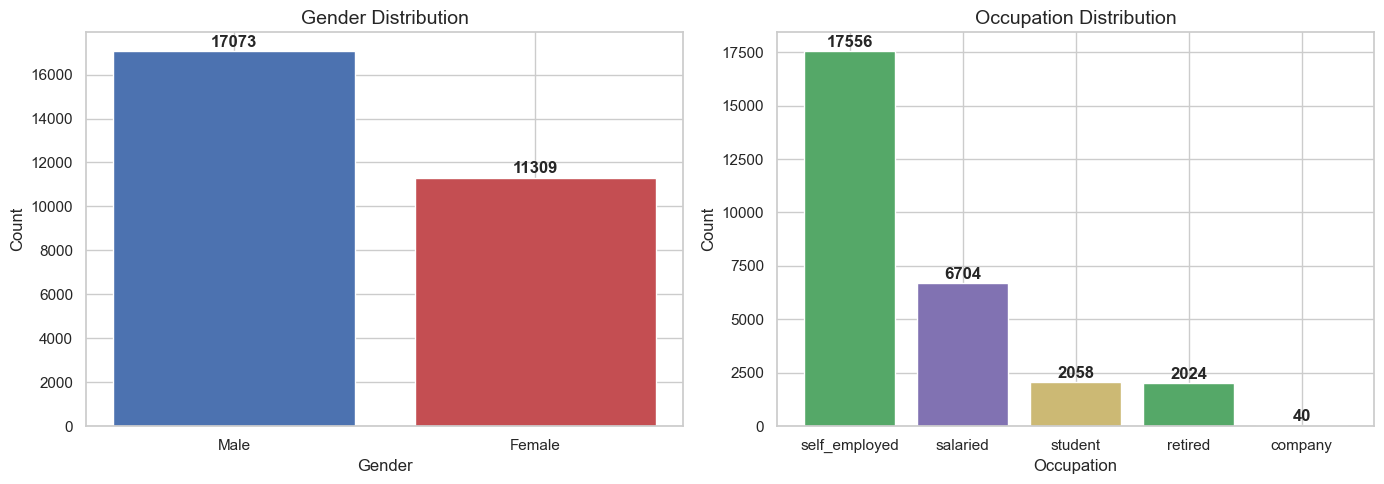

In [9]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Occupation distribution
occ_counts = df['occupation'].value_counts()
axes[1].bar(occ_counts.index, occ_counts.values, color=['#55A868', '#8172B2', '#CCB974'])
axes[1].set_title('Occupation Distribution')
axes[1].set_xlabel('Occupation')
axes[1].set_ylabel('Count')
for i, v in enumerate(occ_counts.values):
    axes[1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** The dataset contains more **male customers** than female. Among occupations, **self-employed** customers form the largest group, followed by salaried employees. This distribution is important for segmented retention strategies.

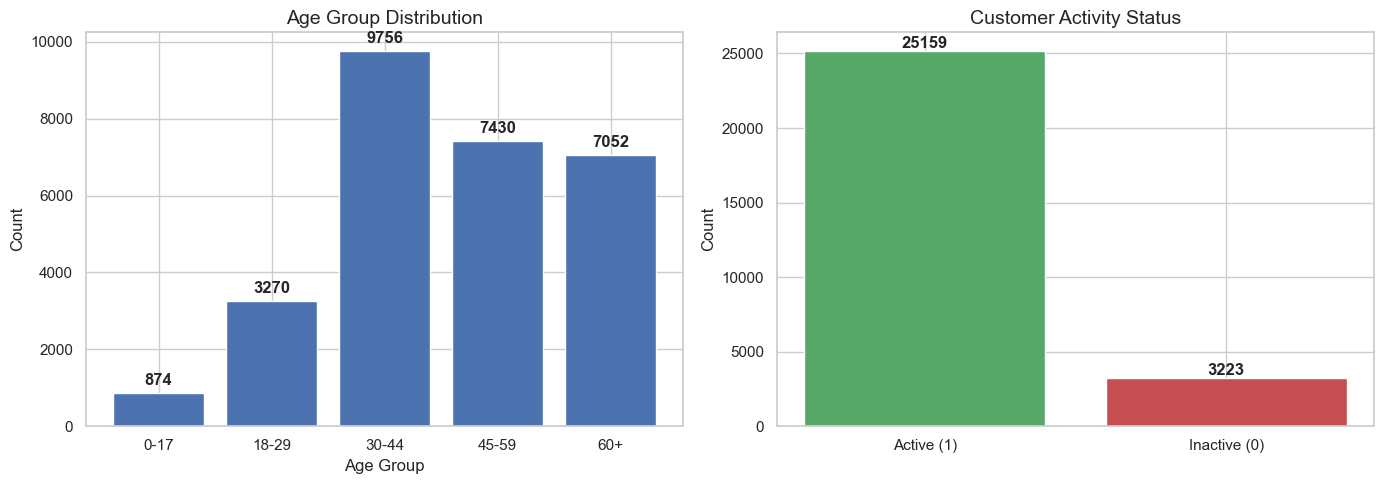

In [10]:
# Age Group distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ag_counts = df['age_group'].value_counts().sort_index()
axes[0].bar(ag_counts.index.astype(str), ag_counts.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Age Group Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
for i, v in enumerate(ag_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# is_active distribution
active_counts = df['is_active'].value_counts()
labels = ['Active (1)', 'Inactive (0)']
colors = ['#55A868', '#C44E52']
axes[1].bar(labels, [active_counts.get(1, 0), active_counts.get(0, 0)], color=colors)
axes[1].set_title('Customer Activity Status')
axes[1].set_ylabel('Count')
for i, v in enumerate([active_counts.get(1, 0), active_counts.get(0, 0)]):
    axes[1].text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** The **45–59** and **30–44** age groups dominate the customer base. The vast majority of customers are marked as **active**, but the inactive minority is critical for churn analysis as they may represent disengaged users.